In [1]:
%%capture
!pip install indiafactorlibrary

In [2]:
# Notebook: 05_fund_decomposition
# Series:   pyIndiaFactorInvesting
# Data:     Invespar Indian Factor Library + Nifty sample + Fund sample
# Run in:   Colab / Binder / local
# Author:   Rajan Raju

# Fund Return Decomposition

A fund returned 18% last year. Its benchmark returned 14%. The fund manager claims skill. But how much of that 4% "alpha" is compensation for taking more size risk, tilting toward momentum stocks, or loading on the quality factor? And how much — if any — is genuinely unexplained by systematic factors? This notebook applies the six-factor model and returns-based style analysis to decompose the returns of three anonymised Indian equity funds, moving from raw performance to a precise accounting of what drives returns.

**What you will leave with**
- A complete FF6 decomposition of three funds: factor exposures, alpha, and model fit
- Three distinct alpha measures: active return, six-factor alpha, and prime alpha
- An understanding of when factor models work well (diversified funds) and when they lose power (concentrated portfolios)
- Rolling regressions revealing style drift over time
- A returns-based style analysis (RBSA) testing whether each fund can be replicated with low-cost index trackers
- A framework for evaluating any fund using only its NAV series

**Prerequisites:** Notebooks 02 (factor construction), 03/03a (regression toolkit and factor models)

In [3]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from scipy.optimize import minimize
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

sys.path.insert(0, str(Path('.').resolve().parent))

import indiafactorlibrary as ifl
from src.data import load_nifty_sample, load_fund_sample

In [4]:
# ── ifl user-agent setup ─────────────────────────────────────────────────────
_lib = ifl.IndiaFactorLibrary()
_lib.session.headers.update({'User-Agent': (
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
    'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')})

def read(name):
    return _lib.read(name)

# ── Load data ─────────────────────────────────────────────────────────────────
ff6_raw = read('FF6')[0];  ff6_raw.index = pd.to_datetime(ff6_raw.index)
ff6_full  = ff6_raw / 100
fund_raw  = load_fund_sample()
nifty_raw = load_nifty_sample()

# ── Align to common period ────────────────────────────────────────────────────
common_s  = max(ff6_full.index.min(), fund_raw.index.min(), nifty_raw.index.min())
common_e  = min(ff6_full.index.max(), fund_raw.index.max(), nifty_raw.index.max())
ff6_a     = ff6_full.loc[common_s:common_e]
fund_a    = fund_raw.loc[common_s:common_e]
nifty_a   = nifty_raw.loc[common_s:common_e]
fund_cols   = fund_a.columns.tolist()
factor_cols = ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']
print(f"Period : {common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}  ({len(ff6_a)} months)")
print(f"Funds  : {fund_cols}")

Period : Jan 2015 – Dec 2020  (72 months)
Funds  : ['Fund_A', 'Fund_B', 'Fund_C']


## 1  Why Decompose Fund Returns?

### 1a  Holdings vs Return-Based Analysis

Holdings-based analysis — examining what a fund owns — is the gold standard for understanding a manager's process. But it requires complete, timely holdings data that is rarely available to outside investors. In India, SEBI mandates monthly portfolio disclosure, but with a lag, and the data is not easily machine-readable.

Return-based analysis requires only the fund's NAV series — a single column of monthly numbers. By regressing this series against known risk factors, we can decompose the return into systematic exposures and a residual. The residual is the starting point for evaluating skill.

But "alpha" is not a single number. Raju (2022, SSRN 4107950) distinguishes three measures:

- **Active return:** fund return minus benchmark return. Simple, intuitive, but conflates factor exposure with skill. A fund that loads heavily on SMB5 will show positive active return in periods when small caps outperform — not because of skill, but because of a size tilt the benchmark does not share.
- **Six-factor alpha:** the intercept from the FF6 regression. This controls for MF, SMB5, HML, RMW, CMA, and WML simultaneously. If the intercept is significantly positive, the fund delivers return beyond what these six systematic factors explain.
- **Prime alpha** (Chin et al., 2018): active return minus the factor-explained portion of return. Prime alpha = active return − (β_MF × MF + β_SMB5 × SMB5 + … + β_WML × WML). This isolates the component of active return attributable to factor tilts from the component attributable to everything else.

The distinction matters: Raju (2022, SSRN 4107950, Table 8) found that median rolling active returns were positive for most fund categories, but median six-factor alpha was zero or negative for all categories in the 2017–2022 period. The "alpha" in active returns was factor exposure, not skill.

## 2  Three Funds: First Look

### 2a  Context

The three anonymised funds have appeared throughout this series — first in the risk-return scatter of notebook 00, then in the risk-return landscape of notebook 03. Here we examine them in detail for the first time. All three are Indian equity funds with overlapping histories in the sample period.

The fund data is loaded via `load_fund_sample()` and is already in decimal form. The Nifty 100 is used as a visual benchmark reference throughout this section.

In [5]:
# ── Annualised summary statistics ─────────────────────────────────────────────
def _stats(series, name):
    ann_mean = series.mean() * 12
    ann_vol  = series.std() * np.sqrt(12)
    sharpe   = ann_mean / ann_vol
    skew     = series.skew()
    cum      = (1 + series).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    return pd.Series({'Ann. Return': ann_mean, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
                      'Skewness': skew, 'Max Drawdown': mdd}, name=name)

stats_df = pd.DataFrame([_stats(fund_a[c], c) for c in fund_cols])
disp = stats_df.copy()
for col in ['Ann. Return', 'Ann. Vol', 'Max Drawdown']:
    disp[col] = disp[col].map('{:.1%}'.format)
for col in ['Sharpe', 'Skewness']:
    disp[col] = disp[col].map('{:.2f}'.format)
print(f"Fund Summary  ({common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')})")
print(disp.to_string())

Fund Summary  (Jan 2015 – Dec 2020)
       Ann. Return Ann. Vol Sharpe Skewness Max Drawdown
Fund_A       13.1%    18.9%   0.69    -1.49       -29.1%
Fund_B       14.3%    15.2%   0.94    -1.19       -23.2%
Fund_C        9.4%    21.1%   0.44    -0.73       -34.6%


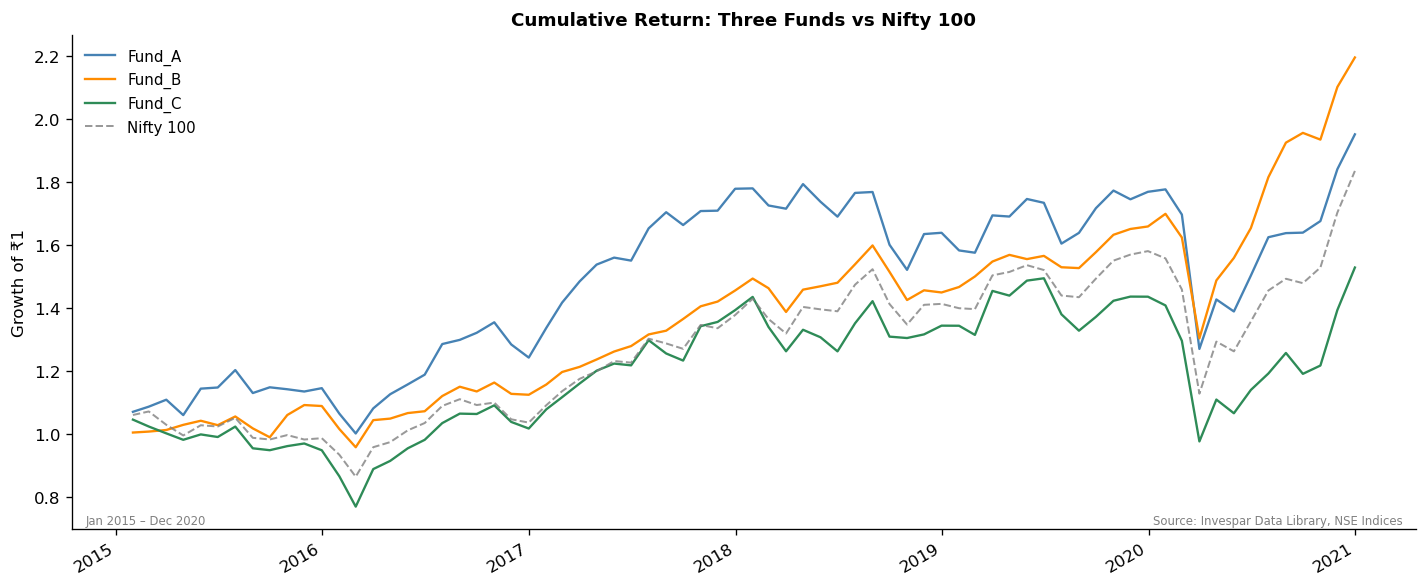

In [6]:
# ── Cumulative return chart: three funds + Nifty 100 reference ────────────────
colors     = ['steelblue', 'darkorange', 'seagreen']
source_str = 'Source: Invespar Data Library, NSE Indices'
period_str = f"{common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}"
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
for col, clr in zip(fund_cols, colors):
    cum = (1 + fund_a[col]).cumprod()
    ax.plot(cum.index, cum.values, label=col, color=clr, linewidth=1.4)
cum_n100 = (1 + nifty_a['nifty100']).cumprod()
ax.plot(cum_n100.index, cum_n100.values, label='Nifty 100',
        color='grey', linewidth=1.2, linestyle='--', alpha=0.8)
ax.set_title('Cumulative Return: Three Funds vs Nifty 100', fontsize=11, fontweight='bold')
ax.set_ylabel('Growth of ₹1', fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 2c  Observations

The summary statistics and cumulative return chart reveal differences across the three funds in return level, volatility, and drawdown depth. The funds share the same sample period but their paths diverge — some funds show steeper cumulative returns alongside sharper drawdowns; others show smoother but lower compounding relative to the Nifty 100 reference line.

These differences could reflect different factor exposures, different skill levels, or both. The regression in the next section will separate the two.

## 3  FF6 Decomposition

### 3a  Applying the Six-Factor Model

We now apply the six-factor model to each fund. The regression decomposes monthly excess returns into factor exposures and a residual. The key outputs: which factors explain each fund's returns, how much variance is explained (R²), and whether any alpha remains.

Each fund's excess return (fund return minus RF) is regressed on MF, SMB5, HML, RMW, CMA, and WML with HAC standard errors (Newey-West, maxlags=3) to correct for serial correlation in the residuals.

In [7]:
# ── FF6 HAC regressions: one model per fund ───────────────────────────────────
reg_results = {}
for col in fund_cols:
    xs = fund_a[col] - ff6_a['RF']
    df = ff6_a[factor_cols].assign(Y=xs)
    reg_results[col] = smf.ols('Y ~ MF + SMB5 + HML + RMW + CMA + WML', data=df).fit(
        cov_type='HAC', cov_kwds={'maxlags': 3}
    )
print(f"FF6 (HAC maxlags=3)  {common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}")
for col, m in reg_results.items():
    print(f"  {col}:  R²={m.rsquared:.3f}  α={m.params['Intercept']:.4f}  (p={m.pvalues['Intercept']:.3f})")

FF6 (HAC maxlags=3)  Jan 2015 – Dec 2020
  Fund_A:  R²=0.914  α=-0.0017  (p=0.424)
  Fund_B:  R²=0.796  α=0.0031  (p=0.119)
  Fund_C:  R²=0.931  α=-0.0018  (p=0.479)


In [8]:
# ── Summary table: FF6 side-by-side ──────────────────────────────────────────
table = summary_col(
    list(reg_results.values()),
    model_names=fund_cols,
    stars=True,
    float_format='%.3f',
    regressor_order=['Intercept', 'MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML'],
    info_dict={'N': lambda m: f"{int(m.nobs)}"}
)
print(table)


                Fund_A   Fund_B   Fund_C 
-----------------------------------------
Intercept      -0.002   0.003    -0.002  
               (0.002)  (0.002)  (0.002) 
MF             1.016*** 0.681*** 1.052***
               (0.057)  (0.058)  (0.055) 
SMB5           -0.030   0.010    -0.089* 
               (0.059)  (0.077)  (0.052) 
HML            0.047    0.099    0.201*  
               (0.092)  (0.100)  (0.110) 
RMW            0.340**  0.010    0.081   
               (0.135)  (0.134)  (0.164) 
CMA            -0.241** -0.242*  0.169   
               (0.094)  (0.125)  (0.122) 
WML            0.115**  0.023    -0.134**
               (0.046)  (0.066)  (0.055) 
R-squared      0.914    0.796    0.931   
R-squared Adj. 0.906    0.778    0.925   
N              72       72       72      
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### 3c  Reading the FF6 Table

Work through the regression table column by column — one column per fund.

- **MF row:** All three funds should show significant positive market exposure. They are equity funds; a near-unit MF loading is expected.
- **SMB5 row:** A positive, significant loading indicates the fund tilts toward smaller stocks relative to the factor universe. A negative loading suggests a large-cap tilt.
- **WML row:** A significant loading suggests the manager — intentionally or not — holds momentum-tilted positions. This is common in actively managed growth-oriented mandates.
- **Intercept (α):** Is it statistically distinguishable from zero? A positive, significant intercept means the six factors do not fully explain the fund's return. A negative intercept suggests the fund generates less return than the factor exposures alone would predict.
- **R²:** How much of monthly return variance do the six factors explain? Raju (2022, SSRN 4107950, Table 4) found average adjusted R² exceeding 0.90 for diversified Indian equity schemes. A substantially lower R² suggests the fund carries significant idiosyncratic risk — concentrated positions, sector bets, or timing that factors cannot capture.

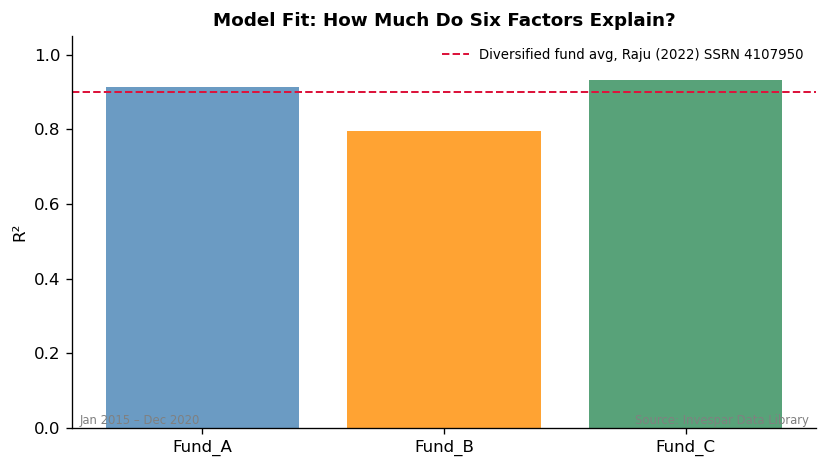

In [9]:
# ── R² bar chart: model fit across three funds ────────────────────────────────
r2_vals    = [m.rsquared for m in reg_results.values()]
source_str = 'Source: Invespar Data Library'
period_str = f"{common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}"
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.bar(fund_cols, r2_vals, color=['steelblue', 'darkorange', 'seagreen'], alpha=0.8)
ax.axhline(0.90, color='crimson', linewidth=1.2, linestyle='--',
           label='Diversified fund avg, Raju (2022) SSRN 4107950')
ax.set_ylim(0, 1.05)
ax.set_title('Model Fit: How Much Do Six Factors Explain?', fontsize=11, fontweight='bold')
ax.set_ylabel('R²', fontsize=10)
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
plt.tight_layout(); plt.show()

## 4  The R² Boundary: When Factor Models Lose Power

### 4a  Diversified vs Concentrated Portfolios

The six-factor model explains over 90% of return variance for diversified mutual funds (Raju 2022, SSRN 4107950, Table 4: average adjusted R² > 0.90 across 98 funds). But explanatory power drops sharply for concentrated portfolios. Raju (2023, SSRN 4344044) found that for 36 Smallcase strategies — rule-based portfolios typically holding 10–30 stocks — median R² under the six-factor model was only 0.68. Raju and Jacob (2024, SSRN 4874166) found that Smallcase strategies in their sample generally showed adjusted R² below 0.60.

The reason is idiosyncratic risk. A 20-stock portfolio carries substantial stock-specific risk that systematic factors cannot explain. The factor model is not wrong — it is simply incomplete for concentrated portfolios. What fills the gap is not "alpha" but uncompensated stock-specific noise.

This has a practical implication: if R² is low, a significant intercept should be interpreted with caution. It may reflect genuine skill — or it may reflect the model's inability to capture the portfolio's idiosyncratic bets.

In [10]:
# ── R² reference levels vs fund results ──────────────────────────────────────
print("R² Reference Levels:")
print(f"  Diversified funds, avg adj. R² > 0.90  (Raju 2022, SSRN 4107950, Table 4)")
print(f"  Smallcase strategies, median R² = 0.68  (Raju 2023, SSRN 4344044)")
print(f"  Smallcase strategies, adj. R² < 0.60   (Raju & Jacob 2024, SSRN 4874166)")
print()
print("Fund R² (from Section 3):")
for col, m in reg_results.items():
    print(f"  {col}: R²={m.rsquared:.3f}  adj. R²={m.rsquared_adj:.3f}")

R² Reference Levels:
  Diversified funds, avg adj. R² > 0.90  (Raju 2022, SSRN 4107950, Table 4)
  Smallcase strategies, median R² = 0.68  (Raju 2023, SSRN 4344044)
  Smallcase strategies, adj. R² < 0.60   (Raju & Jacob 2024, SSRN 4874166)

Fund R² (from Section 3):
  Fund_A: R²=0.914  adj. R²=0.906
  Fund_B: R²=0.796  adj. R²=0.778
  Fund_C: R²=0.931  adj. R²=0.925


### 4c  Interpreting the R² Comparison

Check how Fund_A, Fund_B, and Fund_C compare to the reference levels: above 0.90 suggests the factor model is a reliable lens for that fund; between 0.68 and 0.90 places the fund in the concentrated-strategy range; below 0.60 signals that the regression outputs — including the intercept — should be interpreted with extra caution.

## 5  Three Measures of Alpha

### 5a  Which Alpha Are You Measuring?

With the FF6 regression in hand, we can now compute all three alpha measures introduced in Section 1. Each answers a slightly different question:

- **Active return:** "Did the fund beat its benchmark?"
- **Six-factor alpha:** "Did the fund beat the systematic factors?"
- **Prime alpha:** "Of the fund's active return, how much was factor-driven and how much was not?"

The prime alpha concept (Chin et al., 2018, as applied in Raju 2022, SSRN 4107950) decomposes active return into two parts: the return attributable to factor tilts, and the residual. A fund can have positive active return but zero prime alpha if the active return is entirely explained by factor tilts.

**Important technical note:** prime alpha is **not** the regression residual. The regression residual is fund excess return minus the full regression prediction (intercept + factor-explained return). Prime alpha is active return (fund minus benchmark) minus only the factor-explained component (Σ β_k × factor_k). The two differ because they use different baselines and because the six-factor alpha (intercept) is already netted out of the residual but not of prime alpha.

In [11]:
# ── Three alpha measures ──────────────────────────────────────────────────────
benchmark    = nifty_a['nifty100']
factor_data  = ff6_a[factor_cols]
prime_alphas = {}
alpha_rows   = []
for col in fund_cols:
    m           = reg_results[col]
    betas       = m.params.drop('Intercept')
    factor_exp  = (factor_data * betas).sum(axis=1)
    active_ret  = fund_a[col] - benchmark
    prime_alphas[col] = active_ret - factor_exp
    alpha_rows.append({'Fund': col,
                       'Active Return (ann.)': active_ret.mean() * 12,
                       'Six-Factor α (ann.)':  m.params['Intercept'] * 12,
                       'Prime Alpha (ann.)':   prime_alphas[col].mean() * 12})
alpha_df = pd.DataFrame(alpha_rows).set_index('Fund')
disp = alpha_df.copy()
for c in disp.columns:
    disp[c] = disp[c].map('{:.2%}'.format)
print(f"Three Alpha Measures  ({common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')})")
print("Benchmark: Nifty 100")
print(disp.to_string())

Three Alpha Measures  (Jan 2015 – Dec 2020)
Benchmark: Nifty 100
       Active Return (ann.) Six-Factor α (ann.) Prime Alpha (ann.)
Fund                                                              
Fund_A                1.23%              -2.00%             -7.84%
Fund_B                2.52%               3.71%             -2.13%
Fund_C               -2.47%              -2.10%             -7.94%


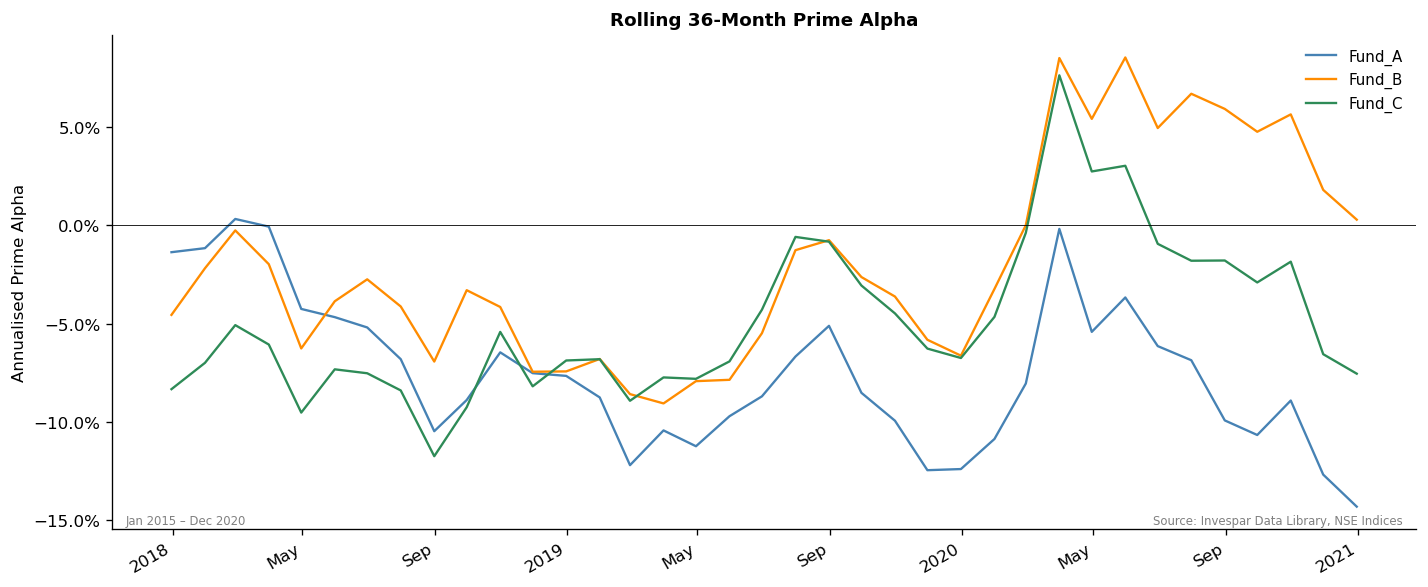

In [12]:
# ── Rolling 36-month annualised prime alpha ───────────────────────────────────
colors     = ['steelblue', 'darkorange', 'seagreen']
source_str = 'Source: Invespar Data Library, NSE Indices'
period_str = f"{common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}"
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
for col, clr in zip(fund_cols, colors):
    rpa = prime_alphas[col].rolling(36).mean().dropna() * 12
    ax.plot(rpa.index, rpa.values, label=col, color=clr, linewidth=1.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Rolling 36-Month Prime Alpha', fontsize=11, fontweight='bold')
ax.set_ylabel('Annualised Prime Alpha', fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 5d  Interpreting the Three Alpha Measures

The table separates the three alpha measures for each fund. A fund with positive active return but near-zero prime alpha is delivering factor exposure, not skill — the return can be replicated with factor-tracking products. A fund with positive prime alpha is doing something the factors cannot explain. Whether that "something" is skill or an omitted risk factor is a question the regression alone cannot answer.

Raju (2022, SSRN 4107950, Table 8) found that no scheme category showed a median positive six-factor alpha in the 2017–2022 period. This provides context for interpreting the Fund_A/B/C results: positive six-factor alpha, if it appears, is statistically unusual relative to the broader Indian fund universe in that period.

## 6  Rolling Exposures: Detecting Style Drift

### 6a  Why Full-Sample Betas Miss Style Drift

A full-sample regression assumes the fund's factor exposures are constant over its entire history. In practice, exposures shift — managers adjust positioning, SEBI rationalisation forces category compliance, and market conditions change the composition of winners and losers.

Rolling regressions reveal this time variation. Raju (2022, SSRN 4107950, Figures 1, 5–7) documented that post-SEBI rationalisation (2017), size exposures converged within categories but widened between categories — Large Cap funds became more consistently large-cap, Small Cap funds more consistently small-cap.

Rolling regressions here use standard OLS (not HAC) within each 36-month window — the window is short enough that heteroskedasticity correction is less critical, and standard OLS produces cleaner rolling estimates.

In [13]:
# ── Local rolling OLS (36-month window, standard OLS per window) ──────────────
# src/factors.rolling_regression has a statsmodels compat issue; this is equivalent.
def _rolling_regression(y_series, X_df, window=36):
    idx = y_series.index.intersection(X_df.index)
    y   = y_series.loc[idx]
    X   = pd.concat([pd.Series(1.0, index=idx, name='const'), X_df.loc[idx]], axis=1)
    out = {}
    for t in range(window, len(y) + 1):
        yw, Xw = y.iloc[t-window:t], X.iloc[t-window:t]
        try:
            f = sm.OLS(yw, Xw).fit()
            out[y.index[t-1]] = {**dict(zip(X.columns, f.params)), 'R2': f.rsquared}
        except Exception:
            out[y.index[t-1]] = {c: np.nan for c in list(X.columns) + ['R2']}
    return pd.DataFrame(out).T

roll_results = {col: _rolling_regression((fund_a[col] - ff6_a['RF']).dropna(),
                                          ff6_a[factor_cols], window=36)
                for col in fund_cols}
print("Rolling window: 36 months  (standard OLS per window)")
for col, r in roll_results.items():
    print(f"  {col}: {r.index.min().strftime('%b %Y')} – {r.index.max().strftime('%b %Y')}  ({len(r)} points)")

Rolling window: 36 months  (standard OLS per window)
  Fund_A: Dec 2017 – Dec 2020  (37 points)
  Fund_B: Dec 2017 – Dec 2020  (37 points)
  Fund_C: Dec 2017 – Dec 2020  (37 points)


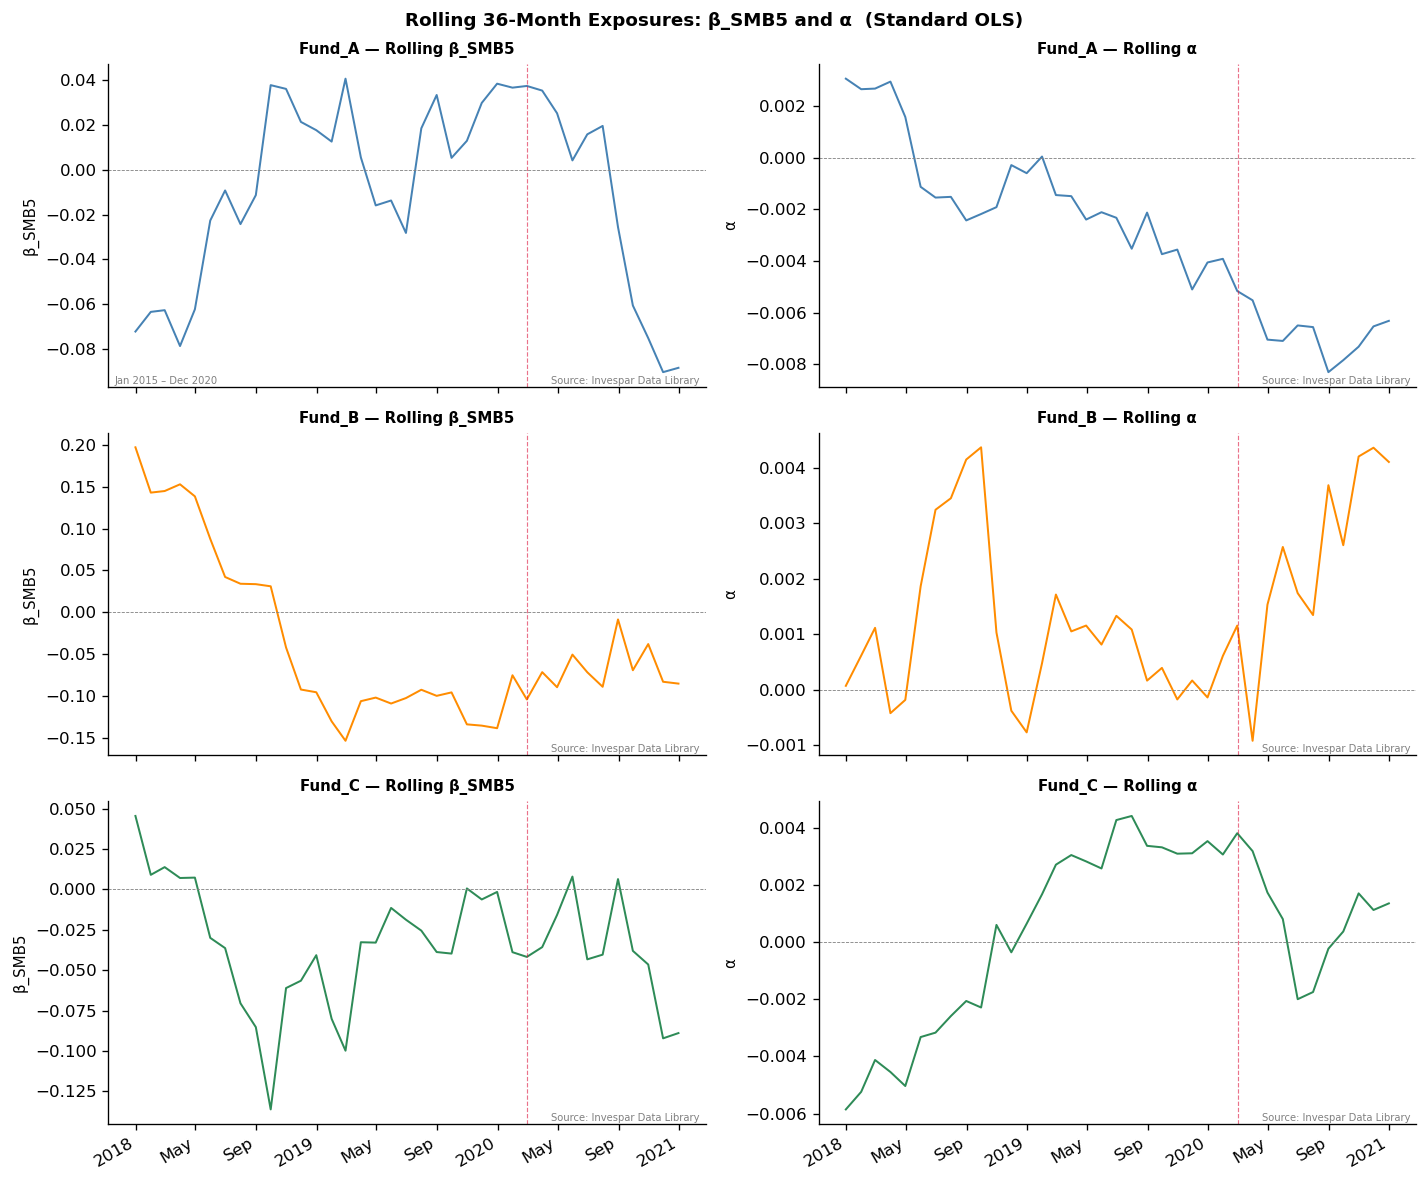

In [14]:
# ── 3×2 rolling exposure chart: β_SMB5 and α per fund ────────────────────────
colors = ['steelblue', 'darkorange', 'seagreen']
covid  = pd.Timestamp('2020-03-01')
source_str = 'Source: Invespar Data Library'
fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=120)
for row_i, (col, clr) in enumerate(zip(fund_cols, colors)):
    r = roll_results[col]
    for ci, (factor, ylabel) in enumerate([('SMB5', 'β_SMB5'), ('const', 'α')]):
        ax = axes[row_i, ci]
        s  = r[factor].dropna()
        ax.plot(s.index, s.values, color=clr, linewidth=1.2)
        ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        if s.index.min() <= covid <= s.index.max():
            ax.axvline(covid, color='crimson', linewidth=0.7, linestyle='--', alpha=0.6)
        ax.set_title(f'{col} — Rolling {ylabel}', fontsize=9, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
        ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=6, color='grey', ha='right')
plt.suptitle('Rolling 36-Month Exposures: β_SMB5 and α  (Standard OLS)', fontsize=11, fontweight='bold')
axes[0, 0].annotate(f"{common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}",
                    xy=(0.01, 0.01), xycoords='axes fraction', fontsize=6, color='grey')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 6c  Reading the Rolling Exposure Charts

The rolling charts reveal whether each fund's factor exposures are stable or shifting. Stable exposures suggest a consistent investment process; shifting exposures suggest style drift — intentional rotation or unintentional drift away from the stated mandate.

Compare the rolling α panels to the full-sample α from Section 3: does the full-sample alpha reflect a persistent phenomenon across the rolling window, or is it concentrated in a single sub-period? A full-sample α that looks significant but is driven by a single episode carries a different interpretation from one that is persistently positive throughout the sample.

## 7  Can You Replicate the Fund? Returns-Based Style Analysis

### 7a  RBSA Framework

The factor regression (Sections 3–5) asks: "what systematic risk premia explain the fund's return?" A complementary question is: "could I have achieved similar returns by holding a passive combination of index trackers?"

Returns-Based Style Analysis (RBSA, Sharpe 1992) answers this by finding the combination of index returns that best tracks the fund — subject to the constraint that weights are non-negative and sum to 1.0. The residual tracking error (ATE) measures how close the replication is.

Raju (2024, SSRN 4854957) applied RBSA to 90 Indian equity funds using nine Nifty indices as style proxies and found that 91.1% had ATEs below 7%, indicating moderate-to-strong replicability. Large Cap funds were the most replicable (100% below 7%); Small Cap funds the least (72% below 7%).

The nine Nifty indices from `load_nifty_sample()` serve as style proxies here. RBSA is implemented via constrained optimisation (scipy SLSQP): minimise the sum of squared residuals subject to weights ≥ 0 and Σweights = 1.

In [15]:
# ── RBSA: constrained optimisation (SLSQP, weights ≥ 0, Σ = 1) ───────────────
nifty_cols   = nifty_a.columns.tolist()
rbsa_results = {}
for col in fund_cols:
    y  = fund_a[col].values
    X  = nifty_a[nifty_cols].values
    n  = len(nifty_cols)
    def obj(w, y=y, X=X): return np.sum((y - X @ w) ** 2)
    res = minimize(obj, np.ones(n)/n, method='SLSQP',
                   bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}])
    w       = res.x / res.x.sum()
    resid   = y - nifty_a[nifty_cols].values @ w
    pseudo_r2 = 1 - resid.var() / fund_a[col].var()
    ate       = resid.std() * np.sqrt(12)
    rbsa_results[col] = {'weights': dict(zip(nifty_cols, w)),
                         'pseudo_R2': pseudo_r2, 'ATE': ate}
    print(f"{col}:  pseudo-R²={pseudo_r2:.3f}  ATE={ate:.2%}")

Fund_A:  pseudo-R²=0.909  ATE=5.71%
Fund_B:  pseudo-R²=0.722  ATE=8.03%
Fund_C:  pseudo-R²=0.947  ATE=4.86%


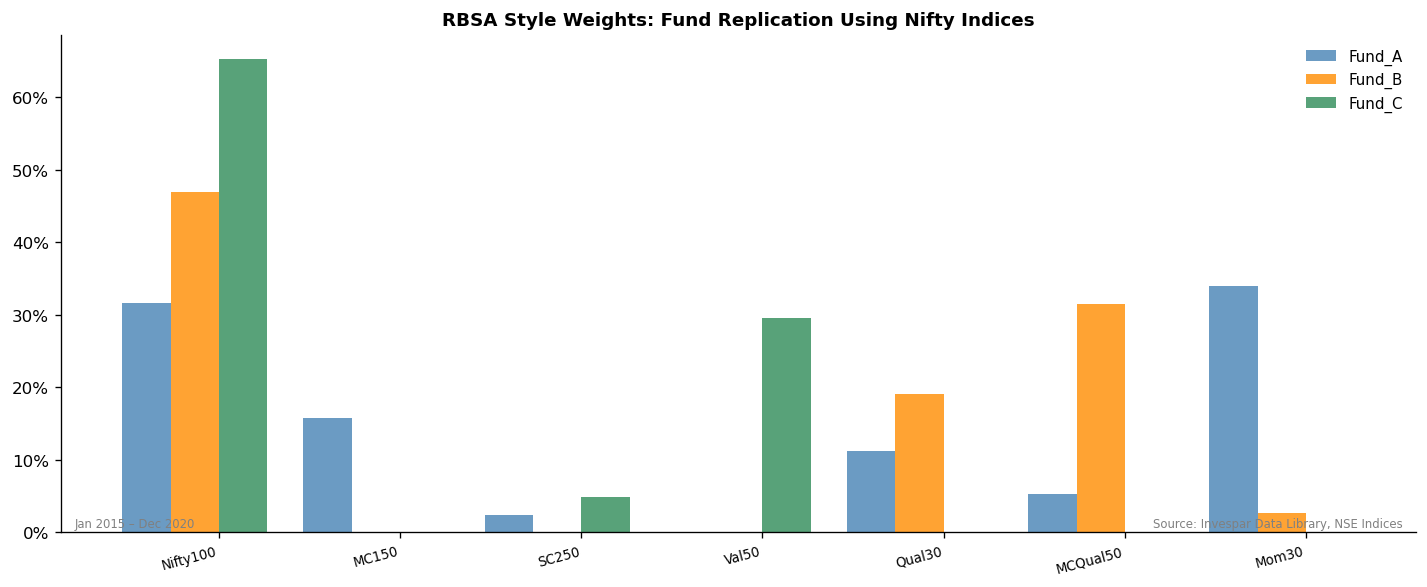

In [16]:
# ── RBSA bar chart: style weights per fund ────────────────────────────────────
nifty_short = {'nifty100': 'Nifty100', 'nifty_midcap150': 'MC150',
               'nifty_smallcap250': 'SC250', 'nifty500_value50': 'Val50',
               'nifty100_quality30': 'Qual30', 'nifty_midcap150_quality50': 'MCQual50',
               'nifty_smallcap250_quality50': 'SCQual50',
               'nifty200_momentum30': 'Mom30', 'nifty_midcap150_momentum50': 'MCMom50'}
weights_df = pd.DataFrame({col: r['weights'] for col, r in rbsa_results.items()}).T
weights_df.columns = [nifty_short.get(c, c) for c in weights_df.columns]
weights_df = weights_df.loc[:, (weights_df > 0.01).any()]
source_str = 'Source: Invespar Data Library, NSE Indices'
period_str = f"{common_s.strftime('%b %Y')} – {common_e.strftime('%b %Y')}"
x = np.arange(len(weights_df.columns));  width = 0.8 / len(fund_cols)
colors = ['steelblue', 'darkorange', 'seagreen']
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
for i, (col, clr) in enumerate(zip(fund_cols, colors)):
    ax.bar(x + i*width, weights_df.loc[col], width=width, label=col, color=clr, alpha=0.8)
ax.set_xticks(x + width * len(fund_cols)/2)
ax.set_xticklabels(weights_df.columns, fontsize=8, rotation=15, ha='right')
ax.set_title('RBSA Style Weights: Fund Replication Using Nifty Indices', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='grey')
ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction', fontsize=7, color='grey', ha='right')
plt.tight_layout(); plt.show()

### 7d  Interpreting RBSA

The RBSA weights show what combination of accessible index trackers would best replicate each fund. The ATE (annualised tracking error of residuals) tells you how close the replication would be.

ATE thresholds from Raju (2024, SSRN 4854957): below 2% = strong replication; 2–4% = good; 4–7% = moderate; above 7% = poor replication.

If a fund's ATE is below 4–7% and its prime alpha (Section 5) is near zero, the fund's returns are replicable at low cost. If the ATE is high and prime alpha is positive, the fund is doing something the style indices cannot capture — which may reflect skill, concentrated bets, or an omitted style dimension.

## 8  What We Established

| Topic | Key Point |
|-------|-----------|
| Three alpha measures | Active return conflates factor exposure with skill; six-factor alpha controls for systematic factors; prime alpha isolates the non-factor component of active return |
| FF6 decomposition | Market factor dominates all three funds; size and momentum loadings differentiate them; R² indicates how much is systematic |
| R² boundary | Diversified funds: avg adj. R² > 0.90; concentrated portfolios: 0.60–0.68; low R² means interpret the intercept with extra caution |
| Rolling exposures | Factor exposures shift over time; full-sample β masks meaningful time variation; compare rolling α to full-sample α |
| RBSA replication | Constrained style weights show what index tracker mix best replicates each fund; ATE measures replication closeness |
| Practical framework | Combine FF6 alpha (is there unexplained return?) with RBSA ATE (can it be replicated?) to form a view on any fund using only its NAV |

**Next:** `06_hypothesis_testing.ipynb` — a template for testing your own factor-based claim on Indian data.

## References

Chin, A., Hao, Y., and Saretto, A. (2018). A Framework for Measuring the Alpha and Tracking Error of Fund Managers. Available at SSRN.

Raju, R. (2022). Factor Exposures and Alpha of Indian Equity Schemes. SSRN Working Paper 4107950.

Raju, R. and Krishnan, H. (2022). Factor Indices in India: Factor Exposures and Style Analysis. SSRN Working Paper 4133389.

Raju, R. (2023). smallcases Investment Performance: A Returns-Based Factor Analysis. SSRN Working Paper 4344044.

Raju, R. (2024). Decoding Active Management: Style Based Replication Strategies in Indian Equity Funds. SSRN Working Paper 4854957.

Raju, R. and Jacob, J. (2024). Don't Judge a Book by its Cover: Evidence of Returns Based Factor Exposures of Multifactor Strategies in India. SSRN Working Paper 4874166.

Sharpe, W.F. (1992). Asset Allocation: Management Style and Performance Measurement. *Journal of Portfolio Management*, 18(2), 7–19.

Invespar (2024). India Factor Library. Accessed March 2026.